In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
import pickle

path = os.getcwd().split(os.sep + 'GUI')[0]
if path not in sys.path:
    print("not here")
    sys.path.append(path)

from neurolib.models.aln import ALNModel
from neurolib.utils import plotFunctions as plotFunc
from neurolib.utils import costFunctions as cost
import neurolib.dashboard.functions as functions
import neurolib.dashboard.data as data
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

#path = os.path.join(os.getcwd(), "plots")

not here


In [2]:
# read case
print(os.getcwd())
case = os.getcwd().split(os.sep)[-1]
print(case[0])

/mnt/antares_raid/home/salfenmoser/neurolib/GUI/current/gui/data/00001
0


### Bistability

In [3]:
aln = ALNModel()
N = aln.params.N

data.set_parameters(aln)

state_vars = aln.state_vars
init_vars = aln.init_vars

##############################################################
def setinit(init_vars_, model):
    state_vars = model.state_vars
    init_vars = model.init_vars
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if model.params[init_vars[iv]].ndim == 2:
                    model.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    model.params[init_vars[iv]][0] = init_vars_[sv]
                    
##############################################################               
def setmaxmincontrol(max_c_c, min_c_c, max_c_r, min_c_r):
    import numpy as np
    
    max_cntrl = np.zeros(( 6 ))
    min_cntrl = np.zeros(( 6 ))
    
    max_cntrl[0] = max_c_c
    min_cntrl[0] = min_c_c
    max_cntrl[1] = max_c_c
    min_cntrl[1] = min_c_c
    max_cntrl[2] = max_c_r
    min_cntrl[2] = min_c_r
    max_cntrl[3] = max_c_r
    min_cntrl[3] = min_c_r
    max_cntrl[4] = max_c_r
    min_cntrl[4] = min_c_r
    max_cntrl[5] = max_c_r
    min_cntrl[5] = min_c_r
            
    return max_cntrl, min_cntrl

#####################################################
def getclosest(k_, found_solution, exc, inh, already_tried_):
    import numpy as np
    if len(found_solution) == 0:
        print("no solutions found")
        return -1
    
    start_ind = -1
    for j_ in found_solution:
        if j_ not in already_tried_ and j_ != k_:
            start_ind = j_
            break
            
    if start_ind == -1:
        return -1
        
    min_dist = np.sqrt((exc[k_] - exc[start_ind])**2 + (inh[k_] - inh[start_ind])**2)
    min_i = start_ind
        
    print(found_solution, already_tried_)
        
    if len(found_solution) == len(already_tried_):
        print("already tried all options")
        min_i = -1
        return min_i
    
    for i_ in found_solution:
        if i_ not in already_tried_:
            if i_ != k_ and i_ != min_i:
                dist_ = np.sqrt((exc[k_] - exc[i_])**2 + (inh[k_] - inh[i_])**2)
                if dist_ < min_dist:
                    min_dist = dist_
                    min_i = i_
                    
    if min_i == 0 and 0 in already_tried_:
        return -1
    
    return min_i

In [4]:
##### LOAD BOUNDARIES
data_file = 'bi.pickle'
with open(data_file,'rb') as f:
    load_array= pickle.load(f)
exc = load_array[0]
inh = load_array[1]
print(len(exc))
#plt.scatter(exc, inh)

152


In [5]:
bestControl_init = [None] * len(exc)
bestState_init = [None] * len(exc)
cost_init = [None] * len(exc)
runtime_init = [None] * len(exc)
grad_init = [None] * len(exc)
phi_init = [None] * len(exc)
costnode_init = [None] * len(exc)
weights_init = [None] * len(exc)

conv_init = [[False]*2] * len(exc)

In [6]:
bestControl_0 = [None] * len(exc)
bestState_0 = [None] * len(exc)
cost_0 = [None] * len(exc)
runtime_0 = [None] * len(exc)
grad_0 = [None] * len(exc)
phi_0 = [None] * len(exc)
costnode_0 = [None] * len(exc)
weights_0 = [None] * len(exc)

conv_0 = [[False]*2] * len(exc)

cgv_list = [None, "HS", "FR", "PR", "CD", "LS", "DY", "WYL", "HZ", None]

In [7]:
initVars = [None] * len(exc)
target = [None] * len(exc)
cost_uncontrolled = [None] * len(exc)

In [8]:
dur_pre = 10
dur_post = 10

n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

tol = 1e-32
start_step = 10.
c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

c_var = [ [0], [1], [0,1]]
p_var = [ [0], [0], [0]]

### CURRENTS
cntrl_vars_0 = [0,1]
prec_vars = [0]

if case[0] == '0':    # low to high
    max_I = [3., -3.]
elif case[0] == '1':
    max_I = [-3., 3.]
    
if case[1] == '0':    # sparsity
    factor_ws = 1.
    factor_we = 0.
elif case[1] == '1':  # energy
    factor_ws = 0.
    factor_we = 1.
    
if case[3] == '0' and case[2] == '0':
    cntrl_vars_init = [0]
elif case[3] == '1' and case[2] == '0':
    cntrl_vars_init = [1]
elif case[3] == '0' and case[2] == '1':
    cntrl_vars_init = [2,4]
elif case[3] == '1' and case[2] == '1':
    cntrl_vars_init = [3,5]

if case[4] == '0':
    dur = 100
    trans_time = 0.8
elif case[4] == '1':
    dur = 400
    trans_time = 0.95
    
maxC = [5., -5., 0.18, 0.]

n_dur = int(np.around(dur/aln.params.dt + 1.,1))
max_cntrl, min_cntrl = setmaxmincontrol(maxC[0], maxC[1], maxC[2], maxC[3])

In [9]:
init_file = 'control_init_' + case + '.pickle'
final_file = 'control_0_' + case + '.pickle'
final_file_1 = 'control_1_' + case + '.pickle'

In [10]:
if os.path.isfile(init_file) :
    print("file found")
    
    with open(init_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_init = load_array[0]
    bestState_init = load_array[1]
    cost_init = load_array[2]
    runtime_init = load_array[3]
    grad_init = load_array[4]
    phi_init = load_array[5]
    costnode_init = load_array[6]
    weights_init = load_array[7]

In [11]:
i_stepsize = 13
i_range = range(0, len(exc),i_stepsize)
data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = 3000.
    
    control0 = aln.getZeroControl()
    control0 = functions.step_control(aln, maxI_ = max_I[0])

    aln.run(control=control0)
    
    target_rates = np.zeros((2))
    target_rates[0] = aln.rates_exc[0,-1] 
    target_rates[1] = aln.rates_inh[0,-1]

    control0 = functions.step_control(aln, maxI_ = max_I[1])
    aln.run(control=control0)

    init_state_vars = np.zeros(( len(state_vars) ))
    for j in range(len(state_vars)):
        if aln.state[state_vars[j]].size == 1:
            init_state_vars[j] = aln.state[state_vars[j]][0]
        else:
            init_state_vars[j] = aln.state[state_vars[j]][0,-1]

    initVars[i] = init_state_vars
    
    aln.params.duration = dur

    target[i] = aln.getZeroTarget()
    target[i][:,0,:] = target_rates[0]
    target[i][:,1,:] = target_rates[1]

-------  0 0.4000000000000001 0.3500000000000001
-------  13 0.47500000000000014 0.40000000000000013
-------  26 0.47500000000000014 0.4750000000000002
-------  39 0.5250000000000001 0.5250000000000002
-------  52 0.5500000000000003 0.5750000000000003
-------  65 0.5500000000000003 0.6250000000000003
-------  78 0.5250000000000001 0.6750000000000004
-------  91 0.5000000000000002 0.7250000000000004
-------  104 0.4250000000000001 0.7750000000000005
-------  117 0.5500000000000003 0.8000000000000005
-------  130 0.47500000000000014 0.8500000000000005
-------  143 0.6000000000000003 0.8750000000000006


In [12]:
data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
    cost.setParams(1.0, 0.0, 0.0)

##### zero control as input for uncontrolled cost
    setinit(initVars[i], aln)
    control0 = aln.getZeroControl()

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 0

    bestControl_init_, bestState_init_, cost_init_, runtime_init_, grad_init_, phi_init_, costnode_init_ = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    cost_uncontrolled[i] = cost_init_[0]

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5902.406479238383
Gradient descend method:  None
RUN  0 , total integrated cost =  5902.406479238383
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  13 0.47500000000000014 0.40000000000000013
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17551.147823015366
Gradient descend method:  None
RUN  0 , total integrated cost =  17551.147823015366
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  26 0.47500000000000014 0.4750000000000002
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17068.886839794224
Gradient descend method:  None
RUN  0 , total integrated cost =  17068.886839794224
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  39 0.5250000000000001 0.5250000000

In [13]:
i_range_ = []

for i in i_range:
    if type(bestControl_init[i]) == type(None):
        i_range_.append(i)

i_range = np.array(i_range_)
        
print(i_range)

[  0  13  26  39  52  65  78  91 104 117 130 143]


In [14]:
factor_iteration = 20.

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
##### zero control as input for uncontrolled cost
    setinit(initVars[i], aln)
    control0 = aln.getZeroControl()

##### initial guess
    weight_ = 10
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    #if prev_i != -1:
    #    control0 = bestControl_init[prev_i][:,:,n_pre-1:-n_post+1]
    
    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(100 * factor_iteration)
    
    weights_init[i] = cost.getParams()

    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_init[i][-j] == 0.:
        j += 1
    
    weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(500 * factor_iteration)

    weights_init[i] = cost.getParams()
    
    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    prev_i = i

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5902.406479238383
Gradient descend method:  None
RUN  1 , total integrated cost =  1500.1173739322473
RUN  2 , total integrated cost =  707.9083111148454
RUN  3 , total integrated cost =  465.37758303800473
RUN  4 , total integrated cost =  324.77204452777676
RUN  5 , total integrated cost =  240.9991433623869
RUN  6 , total integrated cost =  192.23023798274664
RUN  7 , total integrated cost =  157.14345956969873
RUN  8 , total integrated cost =  130.9737299544737
RUN  9 , total integrated cost =  111.41341781941648
RUN  10 , total integrated cost =  96.22722457270967
RUN  11 , total integrated cost =  84.05599450401232
RUN  12 , total integrated cost =  73.82071993465968
RUN  13 , total integrated cost =  66.02717227700177
RUN  14 , total integrated cost =  59.50596142473898
RUN  15 , total integrated cost =  54.17679109925372
RUN  16

ERROR:root:Problem in initial value trasfer


RUN  2000 , total integrated cost =  14.002417014046001
RUN  2000 , total integrated cost =  14.002417014046001
Improved over  2000  iterations in  167.84568989649415  seconds by  99.76276765988078  percent.
Problem in initial value trasfer:  Vmean_exc -56.6276196577562 -56.62761964348191
weight =  4215.276886352981
set cost params:  1.0 0.0 4215.276886352981
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5899.18661620175
Gradient descend method:  None
RUN  1 , total integrated cost =  5780.149560625689
RUN  2 , total integrated cost =  5772.051358444286
RUN  3 , total integrated cost =  5764.536766994668
RUN  4 , total integrated cost =  5762.47600825943
RUN  5 , total integrated cost =  5759.464181677064
RUN  6 , total integrated cost =  5757.875522378335
RUN  7 , total integrated cost =  5753.753151513107
RUN  8 , total integrated cost =  5750.869311539856
RUN  9 , total integrated cost =  5721.012583826185
RUN  10 , total integrated cost =  5720.64282630670

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  404 , total integrated cost =  5448.958268534634
Improved over  404  iterations in  30.146126249805093  seconds by  7.632041109372466  percent.
Problem in initial value trasfer:  Vmean_exc -56.62731391672376 -56.62731518183929
-------  13 0.47500000000000014 0.40000000000000013
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17551.147823015366
Gradient descend method:  None
RUN  1 , total integrated cost =  714.7503683120922
RUN  2 , total integrated cost =  515.3457342140781
RUN  3 , total integrated cost =  350.2148360229487
RUN  4 , total integrated cost =  247.87140951269285
RUN  5 , total integrated cost =  171.29440264757113
RUN  6 , total integrated cost =  125.51848684932604
RUN  7 , total integrated cost =  89.31703988643962
RUN  8 , total integrated cost =  68.75866261896259
RUN  9 , total integrated cost =  54.37604181055294
RUN  10 , total integrated cost =  45.2246226526801
RUN  11

...

RUN  140 , total integrated cost =  27212.81395676797
RUN  150 , total integrated cost =  27186.1136746017
RUN  160 , total integrated cost =  27185.703286660446
RUN  170 , total integrated cost =  27185.061936162074
RUN  180 , total integrated cost =  27184.05688742279
RUN  190 , total integrated cost =  27183.897172616213
RUN  200 , total integrated cost =  27183.643270529752


ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  230 , total integrated cost =  27181.73675122073
Improved over  230  iterations in  23.55805435590446  seconds by  5.327125885102973  percent.
Problem in initial value trasfer:  Vmean_exc -56.70408561775972 -56.70408542661978
-------  130 0.47500000000000014 0.8500000000000005
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  14547.979043359295
Gradient descend method:  None
RUN  1 , total integrated cost =  14547.979043359295
Control only changes marginally.
RUN  1 , total integrated cost =  14547.979043359295
Improved over  1  iterations in  0.14880797639489174  seconds by  0.0  percent.
weight =  10.0
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  14547.979043359295
Gradient descend method:  None
RUN  1 , total integrated cost =  14547.979043359295
Control only changes marginally.
RUN  1 , total integrated cost =  14547.979043359295
Impro

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  494 , total integrated cost =  37722.32314891356
Improved over  494  iterations in  43.272123293951154  seconds by  2.30160640153629  percent.
Problem in initial value trasfer:  Vmean_exc -56.70027514390805 -56.70027512889475


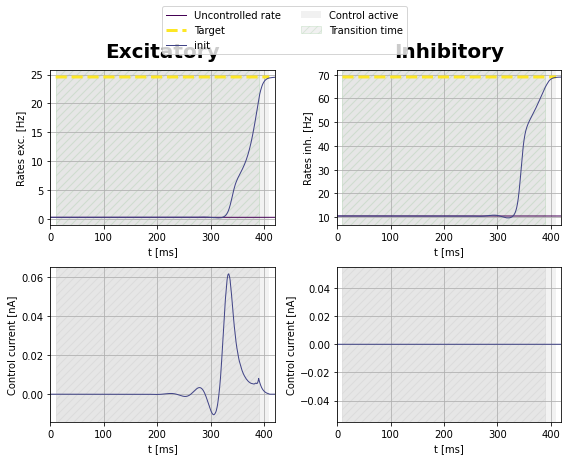

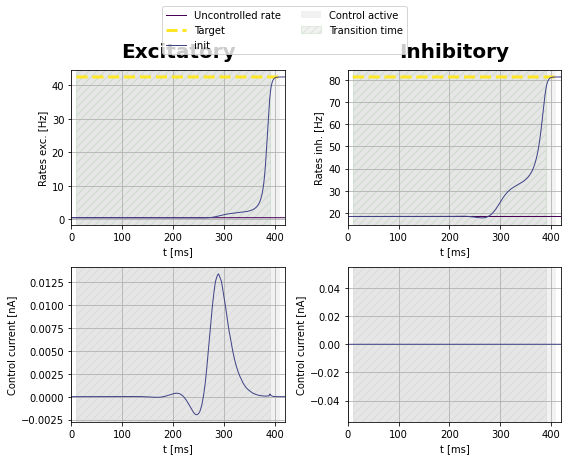

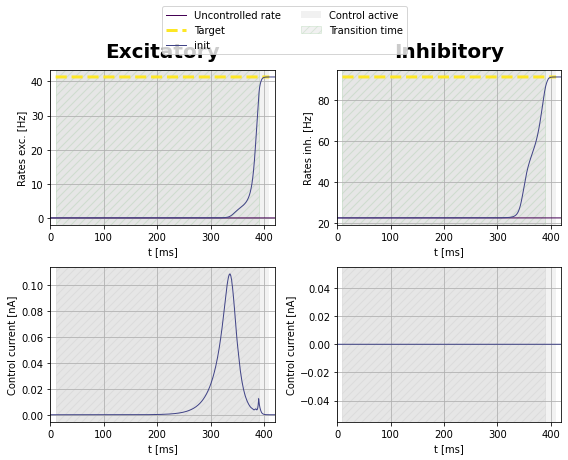

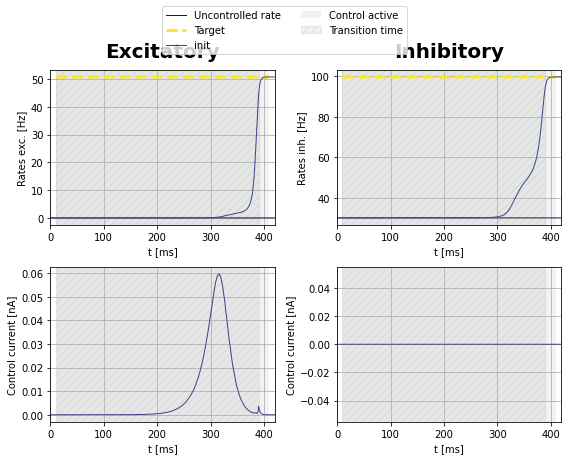

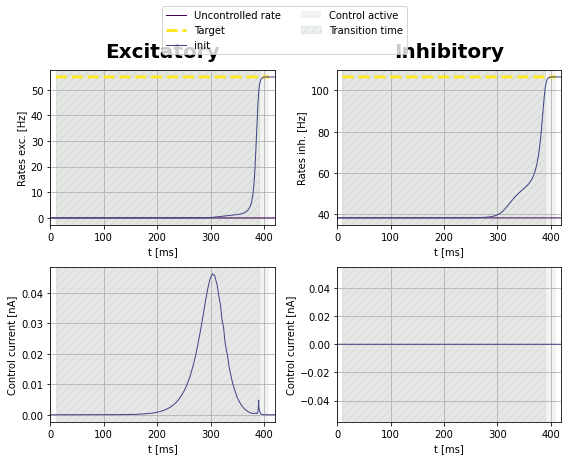

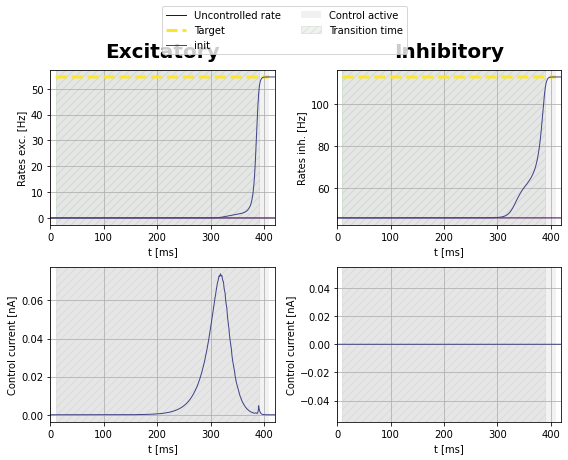

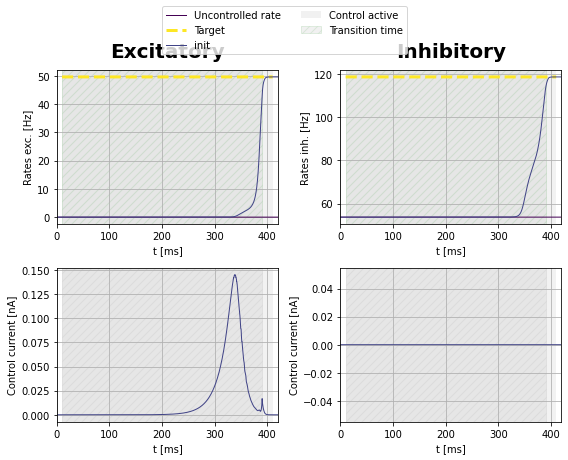

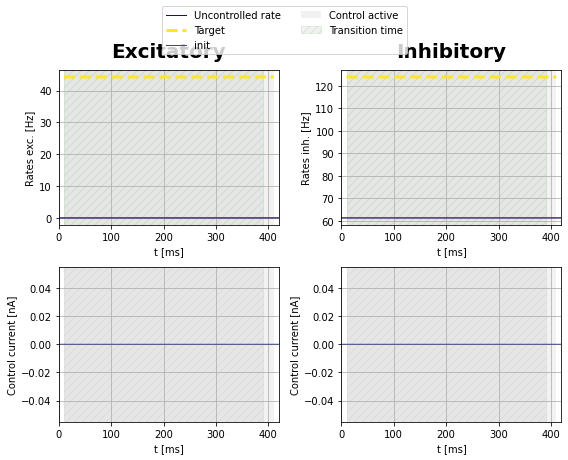

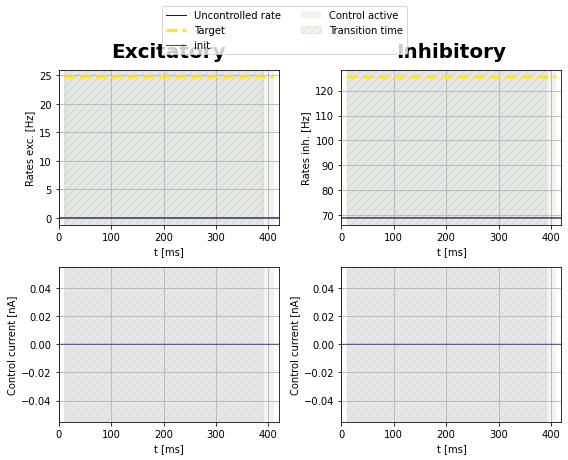

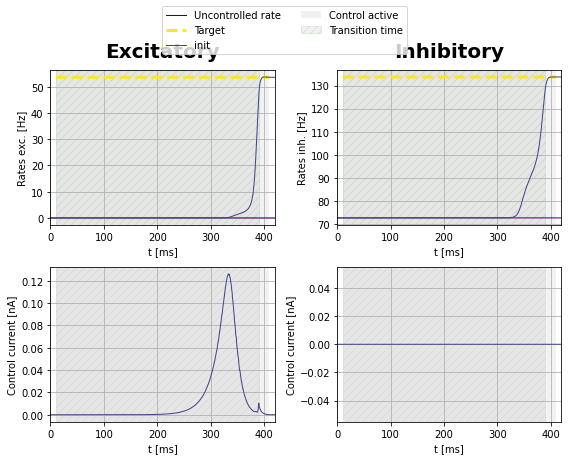

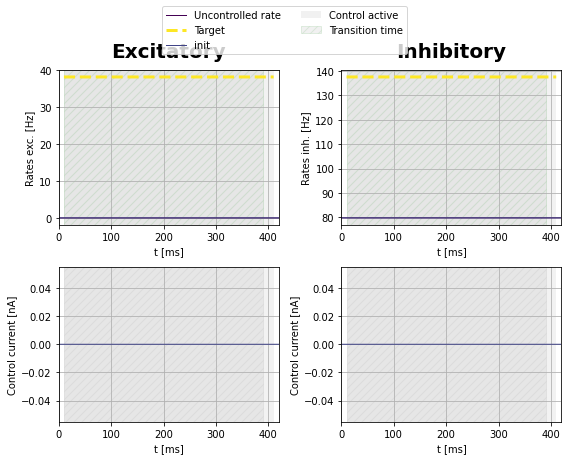

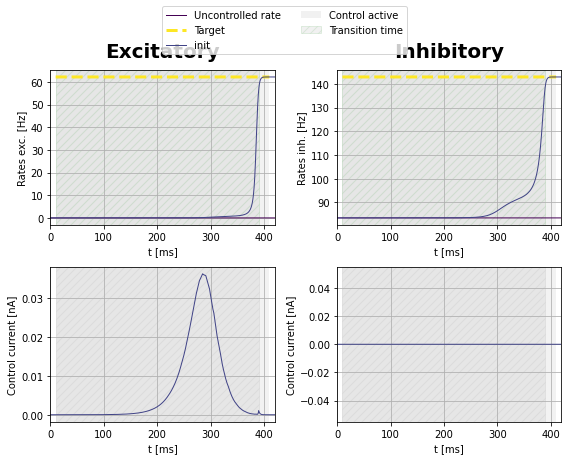

In [15]:
#plot initial guesses

for i in i_range:
        
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i]],
        [costnode_init[i]], [weights_init[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)

In [16]:
found_solution = []
no_solution = []
last_update = -1
factor_iteration = 20.
already_tried = [ [] for _ in range(len(exc)) ]
i_range = range(0, len(exc),i_stepsize)
i_range_0 = []
i_range_1 = []

print(already_tried, len(already_tried))

for k in range(len(i_range)**2):
    print('------------------------------------------------------------')
    print('--------------------', k)
    print('------------------------------------------------------------')
        
    print("found solution: ", found_solution)
    print("no solution: ", no_solution)
    
    if len(i_range) == len(found_solution) + len(no_solution):
        print("found solution for all parameters")
        break
    
    #if last_update != k-1:
    #    print("no improvement from previous step")
    #    break

    for i in i_range:
        print("------- ", i, exc[i], inh[i])

        if np.abs(bestState_init[i][0,0,-1] - target[i][0,0,-1]) < 0.5 * np.abs(
            bestState_init[i][0,0,-1] - bestState_init[i][0,0,0]):
            if i not in found_solution:
                print("found solution for ", i)
                found_solution.append(i)
                #last_update = k
            if i in no_solution:
                no_solution.pop(no_solution.index(i))
            continue

        #if i not in no_solution:
        #    print("no solution for ", i)
        #    no_solution.append(i)
        
        if i not in i_range_0:
            i_range_0.append(i)
            
        if i not in i_range_1:
            i_range_1.append(i)

        closest_ = getclosest(i, found_solution, exc, inh, already_tried[i])
        print("closest index ", closest_)

        weight_ = 10
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
            
        if i != 0 and closest_ != -1:
            control0 = bestControl_init[closest_][:,:,n_pre-1:-n_post+1]
            if closest_ not in already_tried[i]:
                already_tried[i].append(closest_)
                        
        if closest_ == -1:
            print("all options tried already")
            if i not in no_solution:
                no_solution.append(i)
                continue

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int(100 * factor_iteration)

        weights_init[i] = cost.getParams()
        
        print("precision vars = ", prec_vars)

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

        j = 1
        while cost_init[i][-j] == 0.:
            j += 1

        weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int(500 * factor_iteration)

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

[[], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], []] 152
------------------------------------------------------------
-------------------- 0
------------------------------------------------------------
found solution:  []
no solution:  []
-------  0 0.4000000000000001 0.3500000000000001
found solution for  0
-------  13 0.47500000000000014 0.40000000000000013
found solution for  13
-------  26 0.47500000000000014 0.4750000000000002
found so

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  36 , total integrated cost =  19569.04007604096
Improved over  36  iterations in  2.758954105898738  seconds by  0.21640356217017143  percent.
Problem in initial value trasfer:  Vmean_exc -56.69408366688122 -56.694084097390856
-------  104 0.4250000000000001 0.7750000000000005
[0, 13, 26, 39, 52, 65, 78] []
closest index  78
set cost params:  1.0 0.0 10.0
precision vars =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  6157.274577557491
Gradient descend method:  None
RUN  1 , total integrated cost =  6121.765742762145
RUN  2 , total integrated cost =  212.60589045096984
RUN  3 , total integrated cost =  103.7661423996395
RUN  4 , total integrated cost =  90.39849433519016
RUN  5 , total integrated cost =  87.94572029910832
RUN  6 , total integrated cost =  86.9774404576995
RUN  7 , total integrated cost =  86.5315305599355
RUN  8 , total integrated cost =  86.26279999083773
RUN  9 , total integrated cost =  86.098949803

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  78 , total integrated cost =  6114.292976806141
Improved over  78  iterations in  9.030125940218568  seconds by  0.10507973008986937  percent.
Problem in initial value trasfer:  Vmean_exc -56.625577925321885 -56.625576952881865
-------  117 0.5500000000000003 0.8000000000000005
found solution for  117
-------  130 0.47500000000000014 0.8500000000000005
[0, 13, 26, 39, 52, 65, 78, 117] []
closest index  117
set cost params:  1.0 0.0 10.0
precision vars =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  14580.670991112851
Gradient descend method:  None
RUN  1 , total integrated cost =  14549.421188016708
RUN  2 , total integrated cost =  14548.001740855472
RUN  3 , total integrated cost =  14547.979234071743
RUN  4 , total integrated cost =  14547.979043381441
RUN  5 , total integrated cost =  14547.979043360432
RUN  6 , total integrated cost =  14547.97904335934
RUN  7 , total integrated cost =  14547.979043359295
RUN  8 

In [17]:
factor_iteration = 20
full_converge = False
conv_init = [[False]*2] * len(exc)

for i in range(len(conv_init)):
    if i not in i_range:
        conv_init[i] = [True, True]
        
counter = 0

while full_converge == False:
    
    if counter > 100:
        break
        
    print(conv_init[::i_stepsize])
    full_converge = True
    
    for conv in conv_init[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range:        

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
        
        j = 1
        while cost_init[i][-j] == 0.:
            j += 1
            
        if j == cost_init[i].shape[0]-1:
            print("converged for ", i)
            if conv_init[i][0]:
                conv_init[i] = [True, True]
            else:
                conv_init[i] = [True, False]
            continue
    
        print("no convergence")
            
        weight_ = (factor_we * weights_init[i][1] * cost_uncontrolled[i] / cost_init[i][-j]
                   + factor_ws * weights_init[i][2] * cost_uncontrolled[i] / cost_init[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 500 * factor_iteration )

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        counter += 1

[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
no convergence
weight =  4565.061323953685
set cost params:  1.0 0.0 4565.061323953685
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5898.954457173973
Gradient descend method:  None
RUN  1 , total integrated cost =  5898.886461640382
RUN  2 , total integrated cost =  5898.885037695302
RUN  3 , total integrated cost =  5898.884914083593
RUN  4 , total integrated cost =  5898.884888472521
RUN  5 , total integrated cost =  5898.884879488201
RUN  6 , total integrated cost =  5898.884876688527
RUN  7 , total integrated cost =  5898.884875715836
RUN  8 , total integrated cost =  5898.884875373885
RUN  9 , total integrated cost =  5898.884875278543
RUN  10 , total integrated cost =  5898.884875255774
RUN  11 , total integrated co

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  23 , total integrated cost =  5898.884875241609
Improved over  23  iterations in  1.9214032981544733  seconds by  0.0011795638171179235  percent.
Problem in initial value trasfer:  Vmean_exc -56.6272719488988 -56.62727365897679
-------  13 0.47500000000000014 0.40000000000000013
no convergence
weight =  47711.47739023735
set cost params:  1.0 0.0 47711.47739023735
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17550.46925556477
Gradient descend method:  None
RUN  1 , total integrated cost =  17550.4689802053
RUN  2 , total integrated cost =  17550.468906530205
RUN  3 , total integrated cost =  17550.4688881592
RUN  4 , total integrated cost =  17550.46887122077
RUN  5 , total integrated cost =  17550.468864916456
RUN  6 , total integrated cost =  17550.46886307819
RUN  7 , total integrated cost =  17550.46886251814
RUN  8 , total integrated cost =  17550.46886234784
RUN  9 , total integrated cost =  17550.46886229371
RUN  1

ERROR:root:Problem in initial value trasfer


RUN  17 , total integrated cost =  17550.46886226763
Improved over  17  iterations in  1.4546348415315151  seconds by  2.240949442011697e-06  percent.
Problem in initial value trasfer:  Vmean_exc -56.690641454679394 -56.69064221674343
-------  26 0.47500000000000014 0.4750000000000002
no convergence
weight =  6243.475935246969
set cost params:  1.0 0.0 6243.475935246969
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17065.148979432164
Gradient descend method:  None
RUN  1 , total integrated cost =  17065.136933741887
RUN  2 , total integrated cost =  17065.136459372403
RUN  3 , total integrated cost =  17065.136291487324
RUN  4 , total integrated cost =  17065.13617232377
RUN  5 , total integrated cost =  17065.13610611045
RUN  6 , total integrated cost =  17065.136056237912
RUN  7 , total integrated cost =  17065.136023939882
RUN  8 , total integrated cost =  17065.135958917843
RUN  9 , total integrated cost =  17065.13560695854
RUN  10 , total integrated cost

...

RUN  1 , total integrated cost =  38611.78881242608
Control only changes marginally.
RUN  1 , total integrated cost =  38611.78881242608
Improved over  1  iterations in  0.3563688173890114  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.700275147772054 -56.7002751325744
[[False, False], [False, False], [True, False], [True, False], [False, False], [False, False], [False, False], [True, True], [True, True], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
converged for  0
-------  13 0.47500000000000014 0.40000000000000013
converged for  13
-------  26 0.47500000000000014 0.4750000000000002
converged for  26
-------  39 0.5250000000000001 0.5250000000000002
converged for  39
-------  52 0.5500000000000003 0.5750000000000003
converged for  52
-------  65 0.5500000000000003 0.6250000000000003
converged for  65
-------  78 0.5250000000000001 0.6750000000000004
no convergence
weight =  6724.802222590686
set cost par

ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  24571.000440544496
Control only changes marginally.
RUN  1 , total integrated cost =  24571.000440544496
Improved over  1  iterations in  0.3537366036325693  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.70192151487539 -56.70192152678501
-------  91 0.5000000000000002 0.7250000000000004
converged for  91
-------  104 0.4250000000000001 0.7750000000000005
converged for  104
-------  117 0.5500000000000003 0.8000000000000005
converged for  117
-------  130 0.47500000000000014 0.8500000000000005
no convergence
weight =  2224.0977285702156
set cost params:  1.0 0.0 2224.0977285702156
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  14541.440912984332
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  14541.440912984332
Control only changes marginally.
RUN  1 , total integrated cost =  14541.440912984332
Improved over  1  iterations in  0.34410372003912926  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.677306606215616 -56.6773061555438
-------  143 0.6000000000000003 0.8750000000000006
converged for  143
[[True, False], [True, False], [True, True], [True, True], [True, False], [True, False], [False, False], [True, True], [True, True], [True, False], [False, False], [True, False]]
-------  0 0.4000000000000001 0.3500000000000001
converged for  0
-------  13 0.47500000000000014 0.40000000000000013
converged for  13
-------  26 0.47500000000000014 0.4750000000000002
converged for  26
-------  39 0.5250000000000001 0.5250000000000002
converged for  39
-------  52 0.5500000000000003 0.5750000000000003
converged for  52
-------  65 0.5500000000000003 0.6250000000000003
converged for  65
-------  78 0.5250000000000001 0.6750000

In [18]:
print(conv_init[::i_stepsize])

with open(init_file,'wb') as f:
    pickle.dump([bestControl_init, bestState_init, cost_init, runtime_init, grad_init, phi_init,
                 costnode_init, weights_init], f)

[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]


In [19]:
if os.path.isfile(final_file) :
    print("file found")
    
    with open(final_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_0 = load_array[0]
    bestState_0 = load_array[1]
    cost_0 = load_array[2]
    runtime_0 = load_array[3]
    grad_0 = load_array[4]
    phi_0 = load_array[5]
    costnode_0 = load_array[6]
    weights_0 = load_array[7]

In [20]:
i_range_0 = range(0, len(exc),i_stepsize)
i_range_ = []

for i in i_range_0:
    if type(bestControl_0[i]) == type(None):
        i_range_.append(i)

i_range_0 = np.array(i_range_)
        
print(i_range_0)

[  0  13  26  39  52  65  78  91 104 117 130 143]


In [21]:
factor_iteration = 20
    
for i in i_range_0:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

# exc and inh control current 

    setinit(initVars[i], aln)
    aln.params.duration = dur
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1].copy()
    #control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]
 
    cost.setParams(1.0, 0.0, 10.0)

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_ = 100
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = "HS"
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_ = 100 * cost_uncontrolled[i] / cost_0[i][-j] - 1
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  41.26132396111801
Gradient descend method:  None
RUN  1 , total integrated cost =  14.374260822718798
RUN  2 , total integrated cost =  13.226790690869361
RUN  3 , total integrated cost =  13.212485729669709
RUN  4 , total integrated cost =  13.192824336893969
RUN  5 , total integrated cost =  13.17619240890401
RUN  6 , total integrated cost =  13.165834404501362
RUN  7 , total integrated cost =  13.157286916756712
RUN  8 , total integrated cost =  13.146608176942586
RUN  9 , total integrated cost =  13.137304783632901
RUN  10 , total integrated cost =  13.1308109293249
RUN  11 , total integrated cost =  13.125560830369048
RUN  12 , total integrated cost =  13.118898858714651
RUN  13 , total integrated cost =  13.113781574568389
RUN  14 , total integrated cost =  13.10929465590111
RUN  15 , total integrated cost =  13.105714925064959
RU

ERROR:root:Problem in initial value trasfer


RUN  1000 , total integrated cost =  123.03576666232681
RUN  1000 , total integrated cost =  123.03576666232681
Improved over  1000  iterations in  205.38190982863307  seconds by  4.9326049005932475  percent.
Problem in initial value trasfer:  Vmean_exc -56.627685034405346 -56.62768135021969
weight =  4796.309464846601
set cost params:  1.0 0.0 4796.309464846601
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5898.861291959985
Gradient descend method:  None
RUN  1 , total integrated cost =  5882.397274539244
RUN  2 , total integrated cost =  5881.174853890283
RUN  3 , total integrated cost =  5879.236551666959
RUN  4 , total integrated cost =  5878.630138087501
RUN  5 , total integrated cost =  5877.823302222608
RUN  6 , total integrated cost =  5877.231777837831
RUN  7 , total integrated cost =  5876.533324797784
RUN  8 , total integrated cost =  5875.834118607585
RUN  9 , total integrated cost =  5874.968764559457
RUN  10 , total integrated cost =  5874.426412

ERROR:root:Problem in initial value trasfer


RUN  1000 , total integrated cost =  5332.32835395514
RUN  1000 , total integrated cost =  5332.32835395514
Improved over  1000  iterations in  151.20842272043228  seconds by  9.60410679222133  percent.
Problem in initial value trasfer:  Vmean_exc -56.62733419404746 -56.627336325849726
-------  13 0.47500000000000014 0.40000000000000013
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  32.9700846695385
Gradient descend method:  None
RUN  1 , total integrated cost =  3.7386196730676917
RUN  2 , total integrated cost =  3.7370115570514804
RUN  3 , total integrated cost =  3.735565808820807
RUN  4 , total integrated cost =  3.7344442466523367
RUN  5 , total integrated cost =  3.7331432821294968
RUN  6 , total integrated cost =  3.7321501370889227
RUN  7 , total integrated cost =  3.7308331257764924
RUN  8 , total integrated cost =  3.7297564484954346
RUN  9 , total integrated cost =  3.728633404940522
RUN  10 , total integrated cost =  

...

RUN  8 , total integrated cost =  653.9137744827925
Control only changes marginally.
RUN  8 , total integrated cost =  653.9137744827925
Improved over  8  iterations in  2.7672125827521086  seconds by  0.003328688371297517  percent.
Problem in initial value trasfer:  Vmean_exc -56.6772801366875 -56.677280731616975
weight =  2223.7549464554245
set cost params:  1.0 0.0 2223.7549464554245
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  14541.199553651988
Gradient descend method:  None
RUN  1 , total integrated cost =  14539.093994959756
RUN  2 , total integrated cost =  14539.093969906939
RUN  3 , total integrated cost =  14539.093931515794
RUN  4 , total integrated cost =  14539.093669073969
RUN  5 , total integrated cost =  14536.395950654378
RUN  6 , total integrated cost =  14536.390391295206
RUN  7 , total integrated cost =  14536.390308069034
RUN  8 , total integrated cost =  14536.390301949697
RUN  9 , total integrated cost =  14536.390301379344
RUN  10 , t

ERROR:root:Problem in initial value trasfer


RUN  16 , total integrated cost =  14536.390301283436
Control only changes marginally.
RUN  16 , total integrated cost =  14536.390301283436
Improved over  16  iterations in  5.448789792135358  seconds by  0.0330732849845532  percent.
Problem in initial value trasfer:  Vmean_exc -56.67751378017749 -56.677506416276806
-------  143 0.6000000000000003 0.8750000000000006
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  30.117254654256815
Gradient descend method:  None
RUN  1 , total integrated cost =  12.273508821149617
RUN  2 , total integrated cost =  12.27268167678635
RUN  3 , total integrated cost =  12.27157665608265
RUN  4 , total integrated cost =  12.270732929442493
RUN  5 , total integrated cost =  12.270595527514967
RUN  6 , total integrated cost =  12.270409985554618
RUN  7 , total integrated cost =  12.270325343238646
RUN  8 , total integrated cost =  12.270177701228315
RUN  9 , total integrated cost =  12.27007881919227
RUN

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  81 , total integrated cost =  122.04914280026158
Improved over  81  iterations in  23.025706527754664  seconds by  0.3851091164195708  percent.
Problem in initial value trasfer:  Vmean_exc -56.70027430395283 -56.700274360906135
weight =  31636.266013724304
set cost params:  1.0 0.0 31636.266013724304
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  38609.84175776925
Gradient descend method:  None
RUN  1 , total integrated cost =  38577.7953597189
RUN  2 , total integrated cost =  38577.79305444506
RUN  3 , total integrated cost =  38577.79267158186
RUN  4 , total integrated cost =  38577.79239879962
RUN  5 , total integrated cost =  38577.791354341476
RUN  6 , total integrated cost =  38577.567093263686
RUN  7 , total integrated cost =  38577.403506355084
RUN  8 , total integrated cost =  38577.40219829837
RUN  9 , total integrated cost =  38577.40194016829
RUN  10 , total integrated cost =  38577.40171891002
RUN  11 , total 

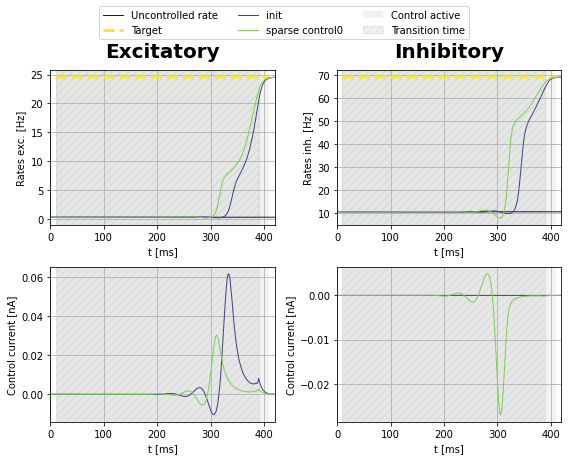

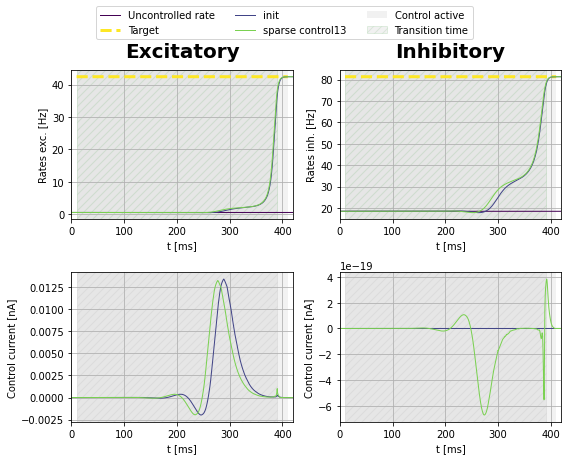

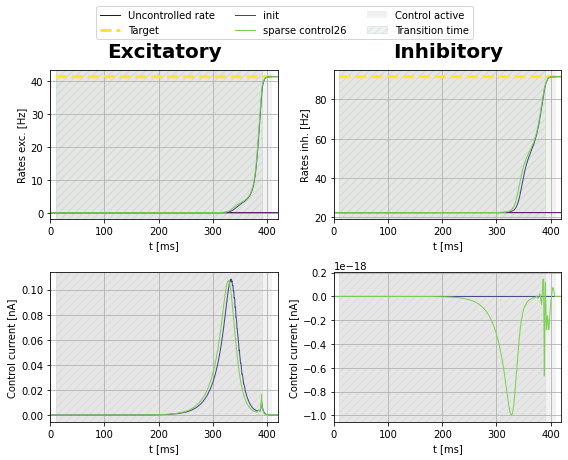

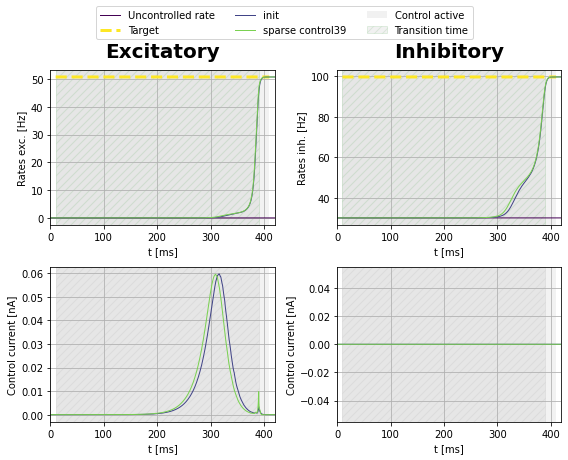

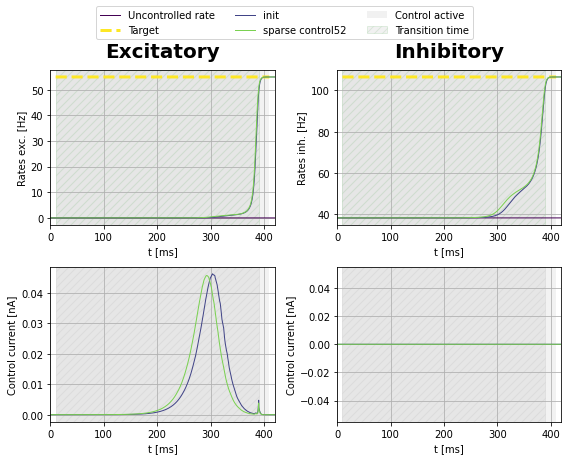

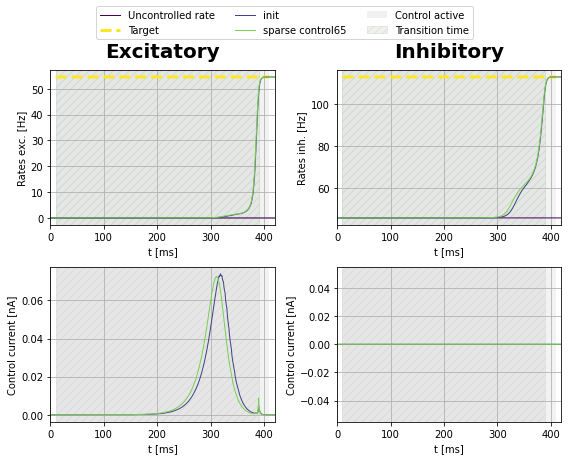

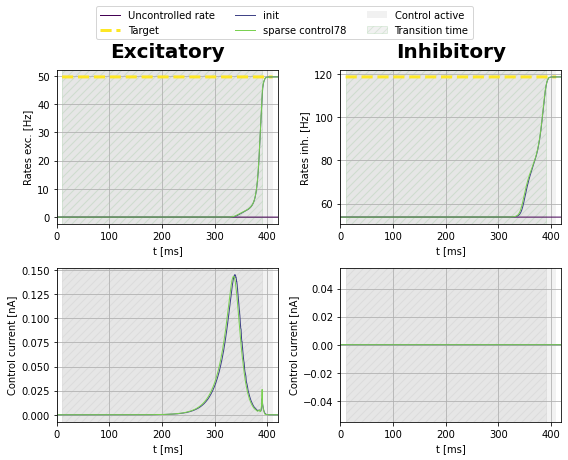

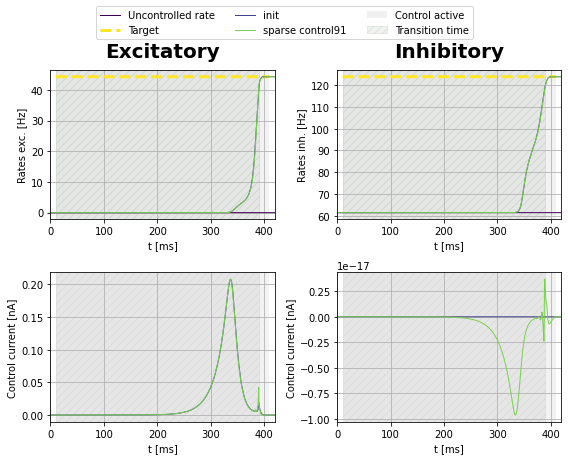

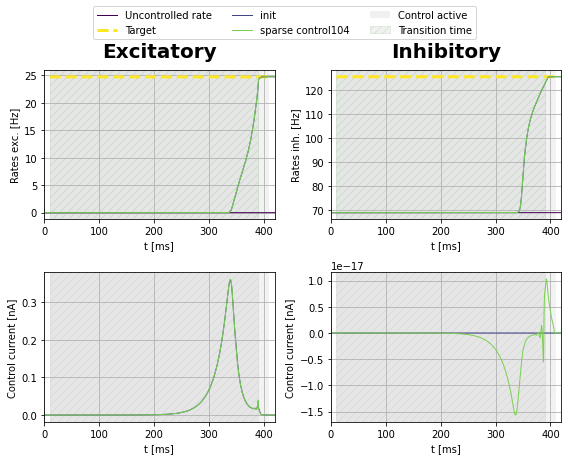

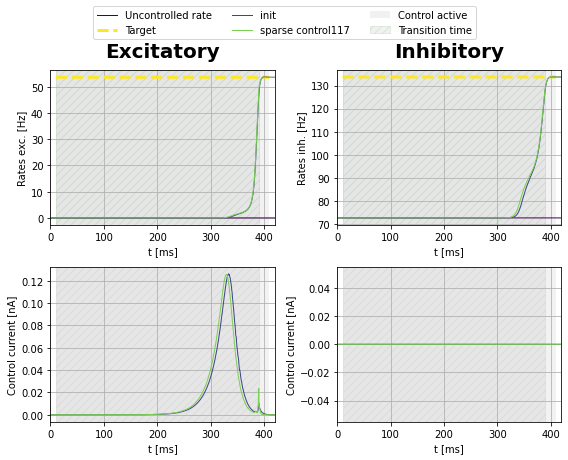

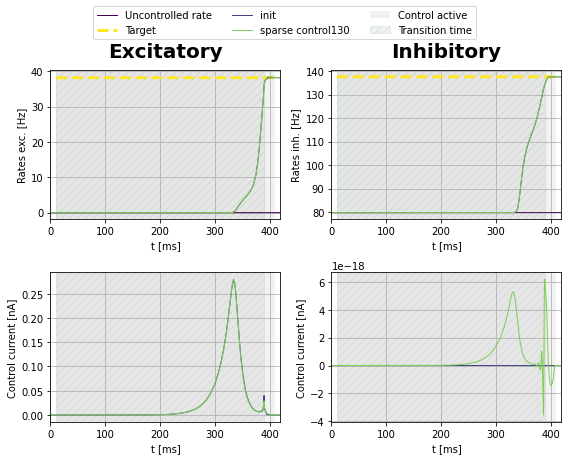

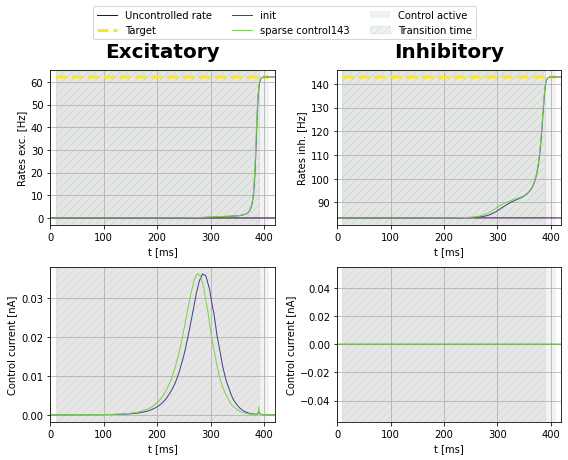

In [22]:
for i in i_range_0:
    
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i], bestControl_0[i]],
        [costnode_init[i], costnode_0[i]], [weights_init[i], weights_0[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)

In [23]:
factor_iteration = 20
full_converge = False
conv_0 = [[False]*2] * len(exc)

for i in range(len(conv_0)):
    if i not in i_range_0:
        conv_0[i] = [True, True]

counter = 0

while full_converge == False:
    print('---------------', counter)
    
    if counter > 100:
        break
    
    print(conv_0[::i_stepsize])
    full_converge = True
    
    for conv in conv_0[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range_0:

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.

        j = 1
        while cost_0[i][-j] == 0.:
            j += 1
            
        if j == cost_0[i].shape[0]-1:
            print("converged for ", i)
            if conv_0[i][0]:
                conv_0[i] = [True, True]
            else:
                conv_0[i] = [True, False]
            continue
    
        print("no convergence")

        weight_ = (factor_we * weights_0[i][1] * cost_uncontrolled[i] / cost_0[i][-j]
                       + factor_ws * weights_0[i][2] * cost_uncontrolled[i] / cost_0[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = 500 * factor_iteration

        weights_0[i] = cost.getParams()

        bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
    counter += 1
    

--------------- 0
[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
no convergence
weight =  5308.08192117329
set cost params:  1.0 0.0 5308.08192117329
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5900.208739051789
Gradient descend method:  None
RUN  1 , total integrated cost =  5898.9699401157895
RUN  2 , total integrated cost =  5898.290720732148
RUN  3 , total integrated cost =  5897.399218292669
RUN  4 , total integrated cost =  5896.733989859543
RUN  5 , total integrated cost =  5896.021280076214
RUN  6 , total integrated cost =  5895.355598356337
RUN  7 , total integrated cost =  5894.760971059745
RUN  8 , total integrated cost =  5894.087411909531
RUN  9 , total integrated cost =  5893.313534640615
RUN  10 , total integrated cost =  5892.646153521837
RUN  11 , to

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  1061 , total integrated cost =  5054.040393687002
Improved over  1061  iterations in  135.5060321651399  seconds by  14.34132897306229  percent.
Problem in initial value trasfer:  Vmean_exc -56.62695453176715 -56.6269590877941
-------  13 0.47500000000000014 0.40000000000000013
no convergence
weight =  48096.49733949348
set cost params:  1.0 0.0 48096.49733949348
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17550.703222218155
Gradient descend method:  None
RUN  1 , total integrated cost =  17550.703086926133
RUN  2 , total integrated cost =  17550.703065233345
RUN  3 , total integrated cost =  17550.70306291242
RUN  4 , total integrated cost =  17550.70306285935
RUN  5 , total integrated cost =  17550.703062859313


ERROR:root:Problem in initial value trasfer


RUN  6 , total integrated cost =  17550.703062859313
Control only changes marginally.
RUN  6 , total integrated cost =  17550.703062859313
Improved over  6  iterations in  2.3572744000703096  seconds by  9.079912075549146e-07  percent.
Problem in initial value trasfer:  Vmean_exc -56.69064740535827 -56.690648002185675
-------  26 0.47500000000000014 0.4750000000000002
no convergence
weight =  6279.9147517948195
set cost params:  1.0 0.0 6279.9147517948195
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17066.14646954451
Gradient descend method:  None
RUN  1 , total integrated cost =  17066.14645577582
RUN  2 , total integrated cost =  17066.146455027585
RUN  3 , total integrated cost =  17066.14645497567
RUN  4 , total integrated cost =  17066.146454972077
RUN  5 , total integrated cost =  17066.14645497175
RUN  6 , total integrated cost =  17066.14645497174
RUN  7 , total integrated cost =  17066.146454971728
RUN  8 , total integrated cost =  17066.146454971717

...

RUN  1 , total integrated cost =  6112.489223230011
Control only changes marginally.
RUN  1 , total integrated cost =  6112.489223230011
Improved over  1  iterations in  0.44554933719336987  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.62557149686948 -56.62557033408919
-------  117 0.5500000000000003 0.8000000000000005
converged for  117
-------  130 0.47500000000000014 0.8500000000000005
no convergence
weight =  2224.5279406856403
set cost params:  1.0 0.0 2224.5279406856403
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  14541.44217662485
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  14541.44217662485
Control only changes marginally.
RUN  1 , total integrated cost =  14541.44217662485
Improved over  1  iterations in  0.4476913847029209  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.67751376789753 -56.677506404329016
-------  143 0.6000000000000003 0.8750000000000006
converged for  143
--------------- 2
[[False, False], [False, False], [False, False], [False, False], [True, False], [False, False], [False, False], [False, False], [False, False], [True, False], [False, False], [True, False]]
-------  0 0.4000000000000001 0.3500000000000001
no convergence
weight =  6201.79222739059
set cost params:  1.0 0.0 6201.79222739059
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5901.441514905087
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  5901.441514905087
Control only changes marginally.
RUN  1 , total integrated cost =  5901.441514905087
Improved over  1  iterations in  0.44987952895462513  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.62692630676216 -56.626931145331525
-------  13 0.47500000000000014 0.40000000000000013
converged for  13
-------  26 0.47500000000000014 0.4750000000000002
converged for  26
-------  39 0.5250000000000001 0.5250000000000002
converged for  39
-------  52 0.5500000000000003 0.5750000000000003
converged for  52
-------  65 0.5500000000000003 0.6250000000000003
converged for  65
-------  78 0.5250000000000001 0.6750000000000004
converged for  78
-------  91 0.5000000000000002 0.7250000000000004
converged for  91
-------  104 0.4250000000000001 0.7750000000000005
converged for  104
-------  117 0.5500000000000003 0.8000000000000005
converged for  117
-------  130 0.47500000000000014 0.8500000000000005
converged for  130
-------  

In [24]:
print(conv_0[::i_stepsize])

with open(final_file,'wb') as f:
    pickle.dump([bestControl_0, bestState_0, cost_0, runtime_0, grad_0, phi_0,
                 costnode_0, weights_0], f)

[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]


In [25]:
bestControl_1 = [None] * len(exc)
bestState_1 = [None] * len(exc)
cost_1 = [None] * len(exc)
runtime_1 = [None] * len(exc)
grad_1 = [None] * len(exc)
phi_1 = [None] * len(exc)
costnode_1 = [None] * len(exc)
weights_1 = [None] * len(exc)

conv_1 = [[False]*2] * len(exc)

In [26]:
if os.path.isfile(final_file_1) :
    print("file found")
    
    with open(final_file_1,'rb') as f:
        load_array = pickle.load(f)

    bestControl_1 = load_array[0]
    bestState_1 = load_array[1]
    cost_1 = load_array[2]
    runtime_1 = load_array[3]
    grad_1 = load_array[4]
    phi_1 = load_array[5]
    costnode_1 = load_array[6]
    weights_1 = load_array[7]

In [27]:
i_range_1 = range(0, len(exc),i_stepsize)
i_range_ = []

for i in i_range_1:
    if type(bestControl_1[i]) == type(None):
        i_range_.append(i)

i_range_1 = np.array(i_range_)  

print(i_range_1)

[  0  13  26  39  52  65  78  91 104 117 130 143]


In [ ]:
factor_iteration = 20

for i in i_range_1:        

    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    cost.setParams(1.0, 1. * factor_we, 1. * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int( 500 * factor_iteration )

    weights_1[i] = cost.getParams()

    bestControl_1[i], bestState_1[i], cost_1[i], runtime_1[i], grad_1[i], phi_1[i], costnode_1[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  23.3749486515917
Gradient descend method:  None
RUN  1 , total integrated cost =  1.0181653089602627
RUN  2 , total integrated cost =  1.0097710431286009
RUN  3 , total integrated cost =  1.0085943832446118
RUN  4 , total integrated cost =  1.0077068046595312
RUN  5 , total integrated cost =  1.0069914132606606
RUN  6 , total integrated cost =  1.0063741858281354
RUN  7 , total integrated cost =  1.0058191951660285
RUN  8 , total integrated cost =  1.0052700399097438
RUN  9 , total integrated cost =  1.0047430438931486
RUN  10 , total integrated cost =  1.0041528788743213
RUN  11 , total integrated cost =  1.0035829848362814
RUN  12 , total integrated cost =  1.003026667882281
RUN  13 , total integrated cost =  1.0024643439934282
RUN  14 , total integrated cost =  1.0018347954150408
RUN  15 , total integrated cost =  1.0012281130674852
R

RUN  10 , total integrated cost =  1.739964029250146
RUN  11 , total integrated cost =  1.7395482132425928
RUN  12 , total integrated cost =  1.7392798868567307
RUN  13 , total integrated cost =  1.7392735214797823
RUN  14 , total integrated cost =  1.7392666363259897
RUN  15 , total integrated cost =  1.7392619596468575
RUN  16 , total integrated cost =  1.7392563636380152
RUN  17 , total integrated cost =  1.7392520591732303
RUN  18 , total integrated cost =  1.7392464953159337
RUN  19 , total integrated cost =  1.7392419397167933
RUN  20 , total integrated cost =  1.7392351167360844
RUN  30 , total integrated cost =  1.7383284525639418
RUN  40 , total integrated cost =  1.7382362902820205
RUN  50 , total integrated cost =  1.7381556636099256
RUN  60 , total integrated cost =  1.738081364681917
RUN  70 , total integrated cost =  1.7380107315488382
RUN  80 , total integrated cost =  1.7379409893252766
RUN  90 , total integrated cost =  1.7378749550270136
RUN  100 , total integrated co

RUN  90 , total integrated cost =  3.660474600088687
RUN  100 , total integrated cost =  3.659854171824769
RUN  110 , total integrated cost =  3.659293934197344
RUN  120 , total integrated cost =  3.6587488145465152
RUN  130 , total integrated cost =  3.6581782966010663
RUN  140 , total integrated cost =  3.6576775038596514
RUN  150 , total integrated cost =  3.657182999417325
RUN  160 , total integrated cost =  3.6566815331473275
RUN  170 , total integrated cost =  3.6561531852509583
RUN  180 , total integrated cost =  3.6545927377636276
RUN  190 , total integrated cost =  3.6541585046839593
RUN  200 , total integrated cost =  3.654026782133226
RUN  300 , total integrated cost =  3.6536028514499868
RUN  400 , total integrated cost =  3.653527690191577
RUN  500 , total integrated cost =  3.6535028880071536
RUN  600 , total integrated cost =  3.6534981349528355
RUN  700 , total integrated cost =  3.653493377034924
RUN  800 , total integrated cost =  3.6534886743563075
RUN  900 , total i

In [ ]:
factor_iteration = 20
full_converge = False

for i in range(len(conv_1)):
    if i not in i_range_1:
        conv_1[i] = [True, True]
        
counter = 0

while full_converge == False:
    
    print('---------------', counter)
    
    print(conv_1[::i_stepsize])
    full_converge = True
    
    for conv in conv_1[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range_1:        

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
        
        j = 1
        while cost_1[i][-j] == 0.:
            j += 1
            
        if j == cost_1[i].shape[0]-1:
            print("converged for ", i)
            if conv_1[i][0]:
                conv_1[i] = [True, True]
            else:
                conv_1[i] = [True, False]
            continue
    
        print("no convergence")
        
        cost.setParams(1.0, 1. * factor_we, 1. * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_1[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 500 * factor_iteration )

        weights_1[i] = cost.getParams()

        bestControl_1[i], bestState_1[i], cost_1[i], runtime_1[i], grad_1[i], phi_1[i], costnode_1[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        counter += 1

In [ ]:
print(conv_1[::i_stepsize])

with open(final_file_1,'wb') as f:
    pickle.dump([bestControl_1, bestState_1, cost_1, runtime_1, grad_1, phi_1,
                 costnode_1, weights_1], f)